In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load your data
df = pd.read_csv('data/benin-malanville.csv', parse_dates=['Timestamp'])
df.head()


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-08-09 00:01:00,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,0.1,122.1,0.0,998,0,0.0,26.3,26.2,NaN
1,2021-08-09 00:02:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,0.0,0.0,0.0,998,0,0.0,26.3,26.2,NaN
2,2021-08-09 00:03:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,0.5,124.6,1.5,997,0,0.0,26.4,26.2,NaN
3,2021-08-09 00:04:00,-1.1,-0.1,-1.0,0.0,0.0,26.2,93.3,0.2,0.7,0.4,120.3,1.3,997,0,0.0,26.4,26.3,NaN
4,2021-08-09 00:05:00,-1.0,-0.1,-1.0,0.0,0.0,26.2,93.3,0.1,0.7,0.3,113.2,1.0,997,0,0.0,26.4,26.3,NaN


In [12]:
# Summary statistics
df.describe()

# Missing value report
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100
missing_report = pd.DataFrame({'Missing Values': missing, 'Percent': missing_percent})
print(missing_report[missing_report['Percent'] > 5])


          Missing Values  Percent
Comments          525600    100.0


In [14]:
from scipy.stats import zscore

cols_to_check = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
z_scores = np.abs(stats.zscore(df[cols_to_check].dropna()))

# Flag outliers (|Z| > 3)
outliers = (z_scores > 3)
df_outliers = df[cols_to_check][outliers.any(axis=1)]
print(f"Outliers found: {df_outliers.shape[0]}")

# Drop or Impute
df[cols_to_check] = df[cols_to_check].apply(lambda x: x.fillna(x.median()))


Outliers found: 7740


In [15]:
df.to_csv('data/eda_clean.csv', index=False)


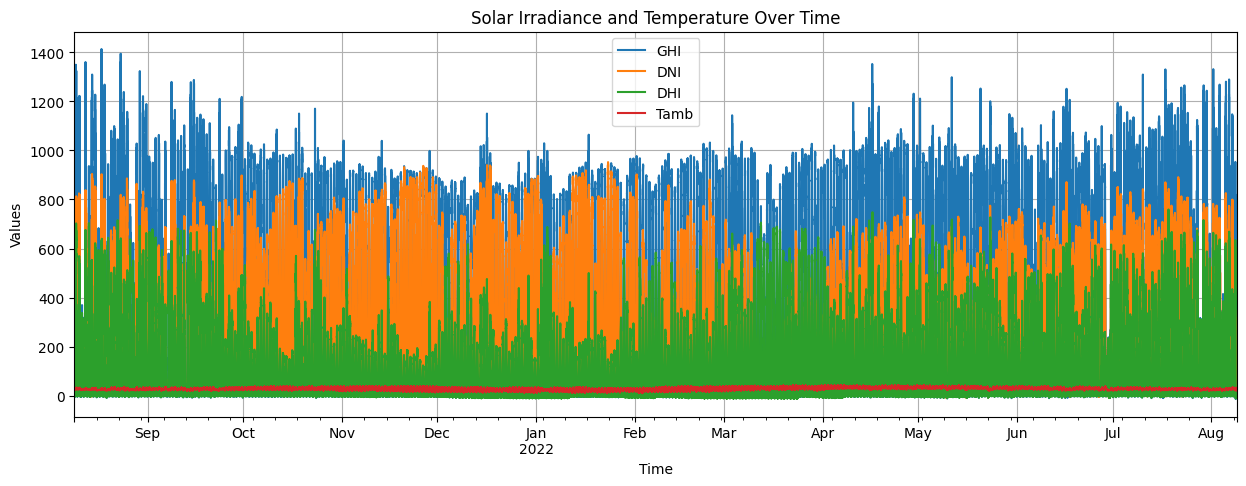

In [16]:
df.set_index('Timestamp')[['GHI', 'DNI', 'DHI', 'Tamb']].plot(figsize=(15,5))
plt.title('Solar Irradiance and Temperature Over Time')
plt.xlabel('Time')
plt.ylabel('Values')
plt.grid(True)
plt.show()


<Axes: xlabel='month'>

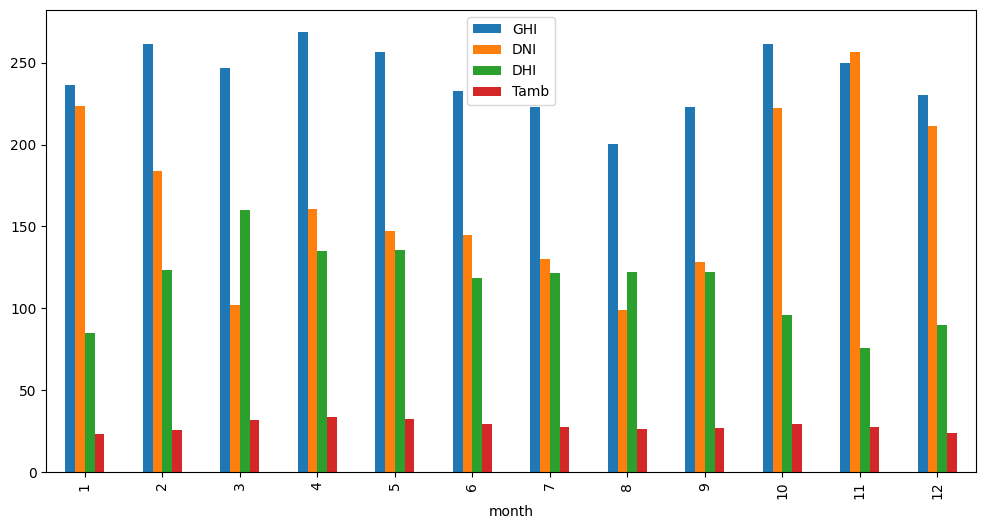

In [17]:
df['month'] = df['Timestamp'].dt.month
monthly_avg = df.groupby('month')[['GHI', 'DNI', 'DHI', 'Tamb']].mean()
monthly_avg.plot(kind='bar', figsize=(12,6))


<Axes: title={'center': 'Sensor Output Before and After Cleaning'}, xlabel='Cleaning'>

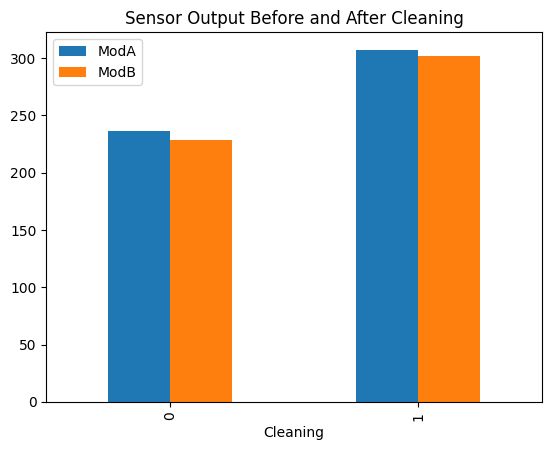

In [18]:

df.groupby('Cleaning')[['ModA', 'ModB']].mean().plot(kind='bar', title='Sensor Output Before and After Cleaning')


<Axes: xlabel='WS', ylabel='GHI'>

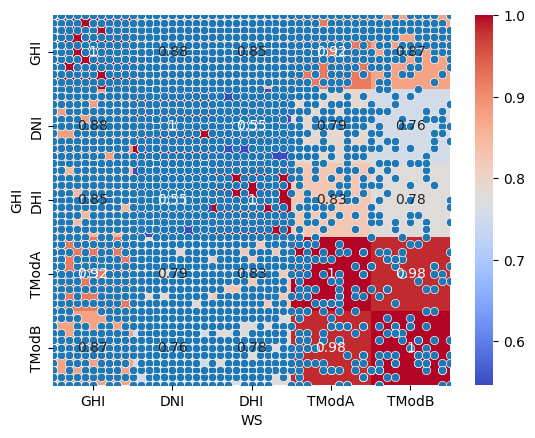

In [19]:
# Heatmap
cor_cols = ['GHI', 'DNI', 'DHI', 'TModA', 'TModB']
sns.heatmap(df[cor_cols].corr(), annot=True, cmap='coolwarm')

# Scatter plots
sns.scatterplot(x='WS', y='GHI', data=df)
sns.scatterplot(x='RH', y='Tamb', data=df)


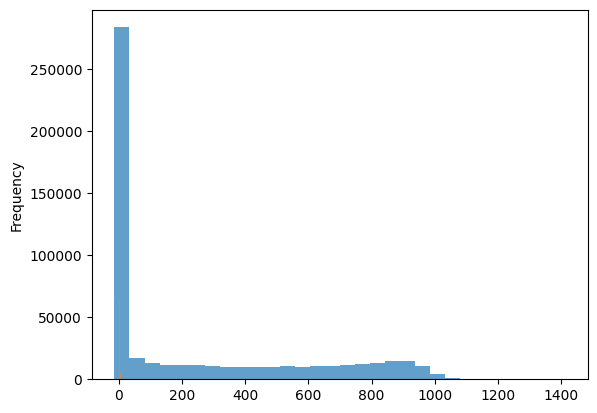

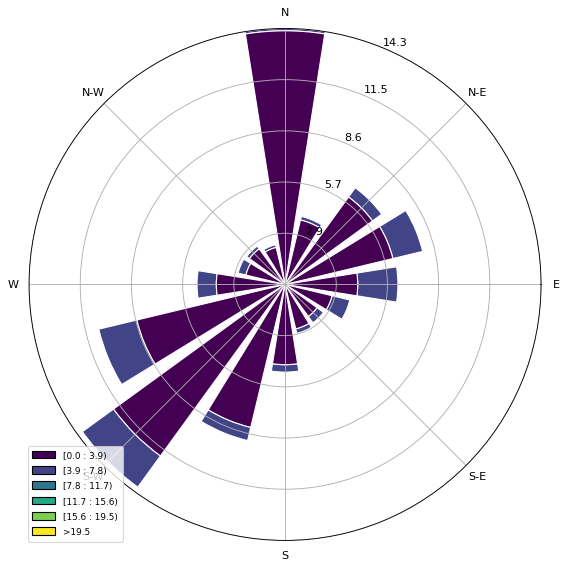

In [23]:

df['GHI'].plot(kind='hist', bins=30, alpha=0.7)
df['WS'].plot(kind='hist', bins=30, alpha=0.7)


from windrose import WindroseAxes

ax = WindroseAxes.from_ax()
ax.bar(df['WD'], df['WS'], normed=True, opening=0.8, edgecolor='white')
ax.set_legend()


<Axes: xlabel='RH', ylabel='Tamb'>

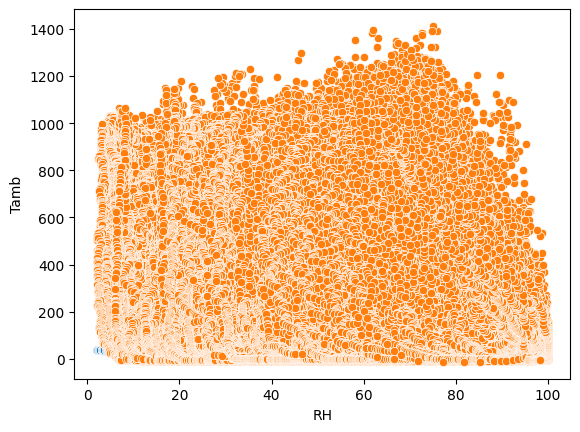

In [21]:
sns.scatterplot(x='RH', y='Tamb', data=df)
sns.scatterplot(x='RH', y='GHI', data=df)


Text(0.5, 1.0, 'GHI vs Tamb (Bubble = RH)')

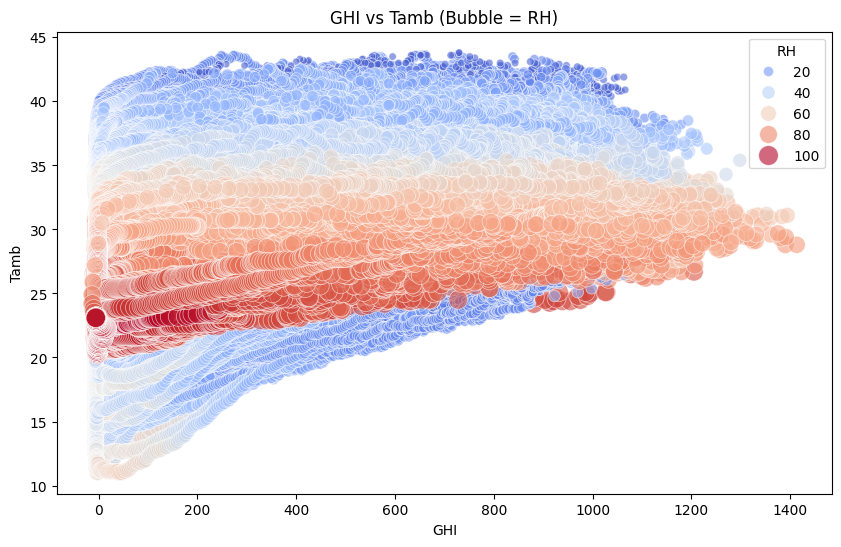

In [22]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='GHI', y='Tamb', size='RH', hue='RH', data=df, alpha=0.6, palette='coolwarm', sizes=(20, 200))
plt.title('GHI vs Tamb (Bubble = RH)')
